# Qwen+GRPO后训练复杂医疗问题推理和疾病诊断

In [1]:
import os
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'      # 使用modelscope下载模型和数据
os.environ['UNSLOTH_DISABLE_STATISTICS'] = '1'  # 禁用 Unsloth 在微调过程中自动收集统计信息
os.environ['OMP_NUM_THREADS'] = '4'             # OpenMP的并行线程设置

In [2]:
# 引入unsloth以及GRPO最新的patch
from unsloth import FastLanguageModel, PatchFastRL
PatchFastRL("GRPO", FastLanguageModel)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 02-22 17:09:16 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.


## 加载unsloth模型

In [3]:
import torch
max_prompt_len = 512
max_output_len = 768 # 
max_seq_length = max_prompt_len +  max_output_len # 512 input + 768 output
lora_rank = 128  # rank越大效果越好，不过速度更慢，显存要求更多

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen2.5-3B-Instruct",
    max_seq_length = max_seq_length,
    load_in_4bit = True, # 基座用4bit量化加载
    fast_inference = True, # 使用vLLM加快推理
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.5, # 如果OOM了，就减少该比例
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ], # 可以根据显存情况去选择微调的参数，例如显存有限且发生OOM了，可以把qkvo4个proj删掉，只微调ffn的linear层
    lora_alpha = lora_rank,
    use_gradient_checkpointing = "unsloth", # unsloth专门做过显存优化，相比transformers库显存降低30%，而且可以实现自动卸载avtivation到cpu
    random_state = 3407,     #随机种子
)

2026-02-22 17:09:20,641 - modelscope - INFO - Target directory already exists, skipping creation.


INFO 02-22 17:09:20 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 02-22 17:09:20 [vllm_utils.py:732] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2025.12.10: Fast Qwen2 patching. Transformers: 4.57.3. vLLM: 0.10.2.
   \\   /|    NVIDIA vGPU-32GB. Num GPUs = 1. Max memory: 31.484 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading /root/.cache/modelscope/hub/models/unsloth/qwen2___5-3b-instruct-unsloth-bnb-4bit with actual GPU utilization = 49.56%
Unsloth: Your GPU has CUDA compute capability 8.9 with VRAM = 31.48 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 1280. Num Sequences = 64.
Unsloth: vLLM's KV Cache can use up to 12.96 GB. Also swap

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 02-22 17:09:27 [__init__.py:1815] Using max model len 1280
WARNING 02-22 17:09:27 [_ipex_ops.py:16] Import error msg: No module named 'intel_extension_for_pytorch'
INFO 02-22 17:09:28 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=6144.
WARNING 02-22 17:09:28 [lora.py:92] `lora_extra_vocab_size` is deprecated and will be removed in v0.12.0. Additional vocabulary support for LoRA adapters is being phased out.
Unsloth: vLLM Bitsandbytes config using kwargs = {'load_in_8bit': False, 'load_in_4bit': True, 'bnb_4bit_compute_dtype': 'bfloat16', 'bnb_4bit_quant_storage': 'uint8', 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': ['lm_head', 'multi_modal_projector', 'merger', 'modality_projection', 'model.layers.2.mlp', 'model.layers.3.mlp', 'model.layers.30.mlp'], 'llm_int8_threshold': 6.0}
INFO 02-22 17:09:28 [core.py:76] Initializing a V1 LLM 

[W222 17:09:29.069552194 ProcessGroupNCCL.cpp:981] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())


...

INFO 02-22 17:09:50 [gpu_model_runner.py:3118] Graph capturing finished in 5 secs, took 0.71 GiB
INFO 02-22 17:09:50 [vllm_utils.py:714] Unsloth: Patched vLLM v1 graph capture finished in 5 secs.


INFO 02-22 17:09:50 [gpu_worker.py:391] Free memory on device (31.17/31.48 GiB) on startup. Desired GPU memory utilization is (0.4955925914437922, 15.6 GiB). Actual usage is 2.66 GiB for weight, 0.58 GiB for peak activation, 0.02 GiB for non-torch memory, and 0.71 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=12333542400` to fit into requested memory, or `--kv-cache-memory=29049711616` to fully utilize gpu memory. Current kv cache memory in use is 13256289280 bytes.
INFO 02-22 17:09:51 [core.py:218] init engine (profile, create kv cache, warmup model) took 20.20 seconds
INFO 02-22 17:09:51 [llm.py:295] Supported_tasks: ('generate',)
INFO 02-22 17:09:51 [__init__.py:36] No IOProcessor plugins requested by the model
Unsloth: Just some info: will skip parsing ['k_norm', 'q_norm', 'post_layernorm', 'input_layernorm', 'pre_feedforward_layernorm', 'post_feedforward_layernorm', 'layer_norm1', 'norm1', 'norm', 'layer_norm2', 'attention_norm', 'post_att

Some weights of Qwen2ForCausalLM were not initialized from the model checkpoint at /root/.cache/modelscope/hub/models/unsloth/qwen2___5-3b-instruct-unsloth-bnb-4bit and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['k_norm', 'q_norm', 'post_layernorm', 'input_layernorm', 'pre_feedforward_layernorm', 'post_feedforward_layernorm', 'layer_norm1', 'norm1', 'norm', 'layer_norm2', 'attention_norm', 'cross_attn_input_layernorm', 'cross_attn_post_attention_layernorm', 'post_attention_layernorm', 'norm2', 'ffn_norm']


Unsloth 2025.12.10 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


## 准备数据

In [4]:
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split

SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""

def get_medical_questions(data_path):
    # 从本地加载json文件
    data = load_dataset("json", data_files=data_path)["train"]
    # 转换成dataframe
    df = data.to_pandas()

    # 99%的数据做训练，1%的数据做测试，大约200条
    train_df, test_df = train_test_split(df, test_size=0.01, random_state=42)

    # 转换回huggingface datasets
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # 构建chat-ml所需要的对话数据格式
    def map_fn(x):
        return {
            'prompt': [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': x['Question']}
            ],
            'answer': x['Response'],  # 参考答案
            'question': x['Question']
        }

    # 处理数据格式，并移除不需要的列
    train_dataset = train_dataset.map(map_fn).remove_columns(['Question', 'Complex_CoT', 'Response', '__index_level_0__'])
    test_dataset = test_dataset.map(map_fn).remove_columns(['Question', 'Complex_CoT', 'Response', '__index_level_0__'])

    return train_dataset, test_dataset

data_path = 'data/FreedomIntelligence/medical-o1-reasoning-SFT/medical_o1_sft.json'
train_dataset, test_dataset = get_medical_questions(data_path)
train_dataset, test_dataset

Map:   0%|          | 0/19506 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

(Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 19506
 }),
 Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 198
 }))

In [5]:
# 根据长度过滤数据
train_dataset = train_dataset.map(lambda x: {"input_len": len(tokenizer.apply_chat_template(x["prompt"]))})
train_dataset = train_dataset.map(lambda x: {"output_len": len(tokenizer(x["answer"])["input_ids"])})
test_dataset = test_dataset.map(lambda x: {"input_len": len(tokenizer.apply_chat_template(x["prompt"]))})
test_dataset = test_dataset.map(lambda x: {"output_len": len(tokenizer(x["answer"])["input_ids"])})
train_dataset = train_dataset.filter(lambda x: x["input_len"] <= max_prompt_len and x["output_len"] <= max_output_len)
test_dataset = test_dataset.filter(lambda x: x["input_len"] <= max_prompt_len and x["output_len"] <= max_output_len)
train_dataset = train_dataset.remove_columns(['input_len', "output_len"])
test_dataset = test_dataset.remove_columns(['input_len', "output_len"])
train_dataset, test_dataset

Map:   0%|          | 0/19506 [00:00<?, ? examples/s]

Map:   0%|          | 0/19506 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19506 [00:00<?, ? examples/s]

Filter:   0%|          | 0/198 [00:00<?, ? examples/s]

(Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 19489
 }),
 Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 198
 }))

###### Reward Functions
Reward = 0.5 * SemanticCorrectness + 0.4 * PerplexityScore + 0.1 * TagPresence

1.SemanticCorrectness用一个cross-encoder model (`cross-encoder/stsb-roberta-base`)计算和标准答案的语义正确性得分

2.PerplexityScore采用**BioGPT** (`microsoft/biogpt`)计算医学语言流畅性得分和语言质量

3.TagPresence检查输出的答案是否符合先思考后答案的格式

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import CrossEncoder
from typing import List
import re

# ------ Device设置 ------
main_device = "cuda" if torch.cuda.is_available() else "cpu"
reward_device = "cuda" if torch.cuda.is_available() else "cpu"

# ------ 语义正确性得分 ------
semantic_model = CrossEncoder('pretrained/cross-encoder/stsb-roberta-base', device=reward_device)
def semantic_correctness(responses: List[str], answers: List[str]) -> List[float]:
    """Calculate semantic similarity using cross-encoder"""
    with torch.no_grad():            
        inputs = list(zip(responses, answers))
        similarities = semantic_model.predict(inputs, show_progress_bar=False).tolist()
        # 如果回答为空，则输出-1
        similarities = [-1.0 if response == "" else similarity for response, similarity in zip(responses, similarities)]
        return similarities

# ------ 流畅性得分 ------
class PerplexityCalculator:
    def __init__(self, model_name="pretrained/microsoft/biogpt", device=reward_device):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.device = device
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

    def calculate(self, texts: List[str], batch_size=8) -> List[float]:
        perplexities = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            try:
                if not batch: continue
                
                encodings = self.tokenizer(
                    batch, 
                    return_tensors="pt", 
                    padding=True, 
                    truncation=True,
                    max_length=200
                ).to(self.device)
                
                with torch.no_grad():
                    outputs = self.model(**encodings, labels=encodings.input_ids)
                
                loss = outputs.loss
                if torch.isnan(loss):
                    raise ValueError("NaN loss encountered")
                
                batch_perplexity = torch.exp(loss).repeat(len(batch)).cpu().tolist()
                # 如果回答为空，则输出-1
                batch_perplexity = [-1.0 if text == "" else perplex for text, perplex in zip(batch, batch_perplexity)]
                perplexities.extend(batch_perplexity)
                                
            except Exception as e:
                print(f"Error in batch {i//batch_size}: {str(e)}")
                perplexities.extend([1000.0] * len(batch))
        
        return perplexities

perplexity_calculator = PerplexityCalculator()

# ------ 输出格式得分 ------
def tag_presence_reward(completions: List[dict]) -> List[float]:
    """Reward for presence of <reasoning> and <answer> tags"""
    rewards = []
    for completion in completions:
        content = completion[0]['content']
        has_reasoning = bool(re.search(r'<reasoning>.*?</reasoning>', content, re.DOTALL))
        has_answer = bool(re.search(r'<answer>.*?</answer>', content, re.DOTALL))
        reward = 0.5 * has_reasoning + 0.5 * has_answer
        rewards.append(reward)
    return rewards

# ------ 综合加权得分 ------
def combined_reward_func(
    prompts, completions, answer, **kwargs
) -> List[float]:
    # 抽取答案
    responses = []
    valid_indices = []
    full_outputs = []
    for idx, completion in enumerate(completions):
        try:
            generated_content = completion[0]['content'].strip()
            full_outputs.append(generated_content)
            answer_match = re.search(r'<answer>(.*?)</answer>', generated_content, re.DOTALL)
            if answer_match:
                generated_content = answer_match.group(1).strip()
            else:
                responses.append("")  # 如果没有答案，则给空
                valid_indices.append(idx)
                continue
            
            # 处理边界条件：1.输出为空   2.输出复制输入
            user_prompt = prompts[idx][-1]['content']
            if not generated_content or generated_content == user_prompt:
                responses.append("")
                valid_indices.append(idx)
                continue
                
            responses.append(generated_content)
            valid_indices.append(idx)
        except (KeyError, IndexError):
            responses.append("")
            valid_indices.append(idx)
            continue
    
    if not responses:
        return [-1.0] * len(completions)
    
    # 计算rewards
    try:
        processed_answers = answer
        similarities = semantic_correctness(responses, [processed_answers[i] for i in valid_indices])
        perplexities = perplexity_calculator.calculate([full_outputs[i] for i in valid_indices])
        tag_rewards = tag_presence_reward([completions[i] for i in valid_indices])
    except Exception as e:
        print(f"Reward calculation error: {str(e)}")
        return [-1.0] * len(completions)
    
    # 转换成tensor
    sim_scores = torch.nan_to_num(torch.tensor(similarities), nan=0.0)
    perplex_scores = torch.nan_to_num(torch.tensor(perplexities), nan=1000.0)
    tag_scores = torch.tensor(tag_rewards)
        
    # 归一会后的困惑度
    perplex_rewards = 1 / (perplex_scores / (perplex_scores.mean() + 1e-9))
    score_range = perplex_rewards.max() - perplex_rewards.min()
    if score_range < 1e-6:
        perplex_rewards_normalized = torch.ones_like(perplex_rewards) * 0.5
    else:
        perplex_rewards_normalized = (perplex_rewards - perplex_rewards.min()) / score_range
    
    # 加权
    combined = [
        0.5 * sim.item() + 0.4 * pr.item() + 0.1 * tag.item()
        for sim, pr, tag in zip(sim_scores, perplex_rewards_normalized, tag_scores)
        if not torch.isnan(sim) and not torch.isnan(pr) and not torch.isnan(tag)
    ]
    
    # clip rewards，保证在-1~1之间
    final_rewards = [-1.0] * len(completions)
    for idx, reward in zip(valid_indices, combined):
        final_rewards[idx] = max(min(reward, 1.0), -1.0)  # Clamp between -1 and 1
    
    assert len(final_rewards) == len(completions), "Reward mapping error"

    return final_rewards

## GRPO的配置

In [7]:
from trl import GRPOConfig, GRPOTrainer
training_args = GRPOConfig(
    use_vllm=True,  # use vLLM for fast inference!
    learning_rate=5e-6,  # 学习率
    weight_decay=0.001,  # 权重衰减
    warmup_ratio=0.1,    # warmup ratio
    max_grad_norm=0.1,   # 最大梯度范数，防止更新过快
    per_device_train_batch_size=8,    # 如果OOM，可以设置小点，这个值一般是num_generations的倍数
    gradient_accumulation_steps=4,    # 梯度累积步数
    num_generations=8,  # 如果太大，可以设置小点
    max_prompt_length=max_prompt_len,  # 输入长度
    max_completion_length=max_output_len, #输出长度
    max_steps=200,    # 训练最大步数
    save_steps=200,   # 保存模型最大间隔
    lr_scheduler_type="cosine",  # 学习率衰减
    optim="adamw_8bit",  # 优化器
    logging_steps=1,     # 日志打印间隔
    bf16=True,           # 是否启用bf16训练
    report_to="none",    
    output_dir="saved_lora_128/", # checkpoint保存目录，这个只保存lora和optimizer参数
    save_strategy="steps" #保存的策略（按step还是epoch）
)

## 开始训练

In [8]:
trainer = GRPOTrainer(
    model = model,
    processing_class = tokenizer,
    reward_funcs = [
        combined_reward_func
    ],
    args = training_args,
    train_dataset = train_dataset,
)
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,489 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 4 x 1) = 32
 "-____-"     Trainable parameters = 239,468,544 of 3,325,407,232 (7.20% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / combined_reward_func / mean,rewards / combined_reward_func / std
1,0.000900,-0.130413,0.256167,395.156250,205.000000,648.000000,0.000000,395.156250,205.000000,648.000000,0,0,0,0,0,0.001259,-0.130413,0.326006
2,0.000100,-0.097699,0.303591,344.531250,173.000000,617.000000,0.000000,344.531250,173.000000,617.000000,No Log,No Log,No Log,No Log,No Log,0.001089,-0.097699,0.434748
3,0.000000,0.033387,0.211047,304.937500,162.000000,538.000000,0.000000,304.937500,162.000000,538.000000,No Log,No Log,No Log,No Log,No Log,0.000952,0.033387,0.391606
4,0.000200,-0.025190,0.160412,345.593750,198.000000,558.000000,0.000000,345.593750,198.000000,558.000000,No Log,No Log,No Log,No Log,No Log,0.000989,-0.025190,0.548369
5,0.001700,0.043827,0.259437,312.687500,160.000000,487.000000,0.000000,312.687500,160.000000,487.000000,No Log,No Log,No Log,No Log,No Log,0.002110,0.043827,0.382711
6,0.000400,0.012078,0.273743,344.062500,195.000000,616.000000,0.000000,344.062500,195.000000,616.000000,No Log,No Log,No Log,No Log,No Log,0.000968,0.012078,0.469908
7,-0.000200,-0.046196,0.403337,371.218750,138.000000,637.000000,0.000000,371.218750,138.000000,637.000000,No Log,No Log,No Log,No Log,No Log,0.001236,-0.046196,0.437221
8,0.000300,-0.080730,0.092135,375.218750,221.000000,736.000000,0.000000,375.218750,221.000000,736.000000,No Log,No Log,No Log,No Log,No Log,0.001065,-0.080730,0.396481
9,19.062800,0.016199,0.266358,327.031250,179.000000,768.000000,0.031250,312.806458,179.000000,532.000000,No Log,No Log,No Log,No Log,No Log,19062.544016,0.016199,0.339525
10,0.000600,0.138982,0.325180,313.562500,147.000000,525.000000,0.000000,313.562500,147.000000,525.000000,No Log,No Log,No Log,No Log,No Log,0.001242,0.138982,0.517371


TrainOutput(global_step=200, training_loss=47525.70637793447, metrics={'train_runtime': 4109.0223, 'train_samples_per_second': 1.558, 'train_steps_per_second': 0.049, 'total_flos': 0.0, 'train_loss': 47525.70637793447})

## 打印训练日志

In [17]:
history = trainer.state.log_history
print(history[:3])

[{'loss': 0.0009, 'grad_norm': 1.0751858949661255, 'learning_rate': 0.0, 'num_tokens': 14965.0, 'completions/mean_length': 395.15625, 'completions/min_length': 205.0, 'completions/max_length': 648.0, 'completions/clipped_ratio': 0.0, 'completions/mean_terminated_length': 395.15625, 'completions/min_terminated_length': 205.0, 'completions/max_terminated_length': 648.0, 'rewards/combined_reward_func/mean': -0.13041265308856964, 'rewards/combined_reward_func/std': 0.32600629329681396, 'reward': -0.13041265308856964, 'reward_std': 0.25616735219955444, 'frac_reward_zero_std': 0.0, 'completion_length': 395.15625, 'kl': 0.0012593510036822408, 'epoch': 0.00020525451559934318, 'step': 1}, {'loss': 0.0001, 'grad_norm': 0.2584804594516754, 'learning_rate': 2.5000000000000004e-07, 'num_tokens': 29134.0, 'completions/mean_length': 344.53125, 'completions/min_length': 173.0, 'completions/max_length': 617.0, 'completions/clipped_ratio': 0.0, 'completions/mean_terminated_length': 344.53125, 'completio

In [10]:
# 保存日志
import json
with open("saved_lora_128/history_log.txt", "w") as fw:
    fw.write(json.dumps(history, ensure_ascii=False, indent=2))

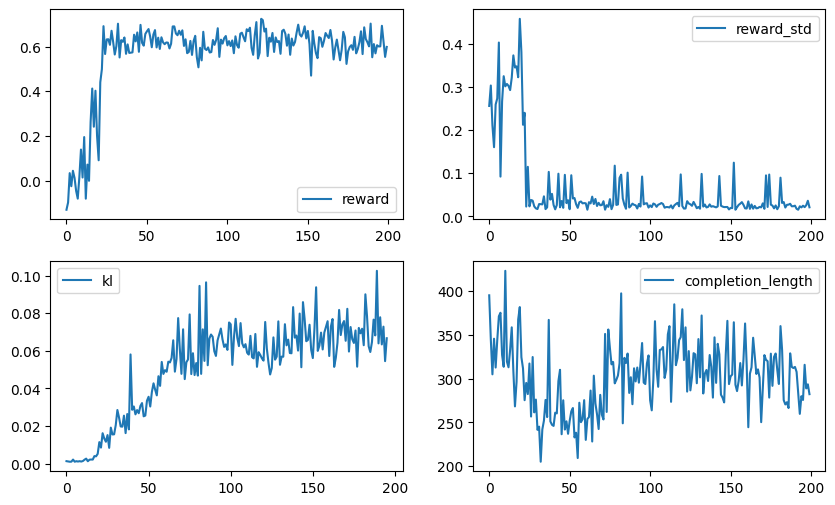

In [18]:
# 画图
import matplotlib.pyplot as plt

reward = [item["reward"] for item in history if "reward" in item]
reward_std = [item["reward_std"] for item in history if "reward_std" in item]
kl = [item["kl"] for item in history if "kl" in item and item["kl"] < 1.0]
completion_length = [item["completion_length"] for item in history if "completion_length" in item]

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(reward, label="reward")
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(reward_std, label="reward_std")
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(kl, label="kl")
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(completion_length, label="completion_length")
plt.legend()
plt.show()
    

In [19]:
# 保存lora
model.save_lora("saved_lora_128/qwen_grpo_medical_reasoning_lora")

# 测试

In [13]:
# GRPO训练前
from vllm import SamplingParams
sampling_params = SamplingParams(
    n=1,
    temperature = 0.8,
    top_p = 0.95,
    max_tokens = 1024,
)
text = tokenizer.apply_chat_template(test_dataset[0]["prompt"], tokenize = False, add_generation_prompt = True)
output = model.fast_generate(
    [text],
    sampling_params = sampling_params,
    lora_request = None,
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
The patient's symptoms of severe abdominal pain, diarrhea, and perianal fistula with stool drainage are indicative of inflammatory bowel disease (IBD), specifically Crohn's disease, which is often associated with dysfunction of the nucleotide oligomerization binding domain 2 (NOD2) protein. Given that the immunohistochemistry results show that NOD2 protein function is impaired, we need to identify which protein is most likely overactive as a result of this dysfunction. 

NOD2 is a cytosolic intramembrane protein that functions as a sensor of peptidoglycan, a component found in the cell walls of Gram-positive bacteria. When NOD2 detects peptidoglycan, it activates downstream signaling pathways to trigger an inflammatory response. If NOD2 is dysfunctional, it could lead to an overproduction of pro-inflammatory cytokines. However, the symptoms suggest an inflammatory process, but the imbalance seems to be directed at a different aspect of the immune response.

Considering the 

In [20]:
# GRPO训练后
text = tokenizer.apply_chat_template(test_dataset[0]["prompt"], tokenize = False, add_generation_prompt = True)
output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved_lora_128/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
In the given scenario, the woman exhibits symptoms including severe abdominal pain, diarrhea, and a perianal fistula with stool drainage. The immunohistochemistry reveals dysfunction of the NOD2 protein, which is a key player in the immune system. Given the symptoms and the dysfunction identified, it is essential to determine which immunological protein is most likely overactive due to this dysfunction. Since NOD2 is involved in the innate immune response, its dysfunction can lead to an overactive immune response, which might manifest as autoimmune or inflammatory conditions.
</reasoning>
<answer>
Based on the given information, the most likely overactive immunological protein due to dysfunction of the NOD2 protein is a cytokine or chemokine that is normally repressed by NOD2. NOD2 is a receptor for microbial products, particularly those from Mycobacterium, and its dysfunction can lead to an overactive immune response. This overactive response can contribute to the symptoms

In [21]:
# 测试中文输入
custom_input = [
  {
      'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n',
      'role': 'system'
  },
  {
      'content': '针对一名30岁患有慢性肾炎6年的男性患者，他的血液化验结果为BUN 118mmol/L，SCr 285μmol/L，血红蛋白80g/L，尿蛋白100mg/dl，根据这些指标，最合适的治疗方案是什么？',
      'role': 'user'
  }
]
text = tokenizer.apply_chat_template(custom_input, tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved_lora_128/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
在分析该患者的情况时，需要考虑多个指标，包括血尿素氮（BUN）、血肌酐（SCr）、血红蛋白（Hb）、尿蛋白等，以确定最佳治疗方案。BUN和SCr水平的升高通常提示肾功能受损，尿蛋白的增加表明肾脏滤过屏障功能受损，血红蛋白的低水平可能指示慢性肾炎导致的贫血。根据这些信息，我们可以推测该患者的肾功能已经显著受损，并且可能伴有贫血。
</reasoning>
<answer>
根据该患者血液化验结果，可以判断其肾功能严重受损，且存在贫血症状。因此，最合适的治疗方案应包括以下几个方面：

1. **肾脏疾病治疗**：针对慢性肾炎，首先应该使用针对肾炎类型的药物进行治疗，如使用ACE抑制剂或ARB类药物来控制血压和减少蛋白尿，降低肾小球损伤风险。同时，根据具体病因（如细菌感染、免疫介导等），可能还需要使用抗生素或其他相关药物。

2. **贫血治疗**：血红蛋白水平为80g/L，明显低于正常范围，即男性血红蛋白正常范围为130-180g/L，需要进行补充铁剂、维生素B12和叶酸的治疗，以增加红细胞生成。在一些情况下，可能还需要进行血液透析治疗以清除体内的毒素和废物。

3. **生活方式调整**：建议患者调整生活方式，如限制蛋白质摄入、低盐饮食、减少水分摄入，以及戒烟限酒等，以减轻肾脏负担。

4. **定期监测**：定期进行肾功能、血红蛋白及尿蛋白的复查，以监测治疗效果及调整治疗方案。

综上所述，针对该患者，建议综合应用药物治疗（包括降压、控制蛋白尿的药物，以及改善贫血的药物）、生活方式调整和定期监测，以控制病情进展，改善患者的生活质量。</answer>


In [24]:
# 测试糖尿病酮症酸中毒 (DKA)
custom_input = [
  {
      'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n',
      'role': 'system'
  },
  {
      'content': '''背景: 24岁女性，王XX，因“恶心、呕吐、意识模糊1天”被送入急诊。关键病史: 1型糖尿病史10年，使用胰岛素泵治疗。3天前有感冒症状，食欲差，自行减少了胰岛素用量。
核心体征与化验: 体征: 生命体征: P 125次/分, R 30次/分 (深大呼吸), BP 95/60 mmHg。神志嗜睡，皮肤干燥，呼吸有烂苹果味。
急诊化验: 血糖: 28.5 mmol/L, 动脉血气 (ABG): pH 7.15, PaCO₂ 22 mmHg, HCO₃⁻ 8 mmol/L, 尿常规: 尿酮 +++, 尿糖 ++++, 血钾: 3.2 mmol/L. 
问题1: 该患者最可能的诊断是什么？ 
问题2: 诊断的核心依据是什么？（请列出三联征） 
问题3: 治疗该患者时，最优先、最紧急的初始治疗步骤是什么？
A. 立即静脉推注胰岛素 
B. 立即大量静脉补液 
C. 立即静脉滴注碳酸氢钠纠正酸中毒 
D. 立即静脉补钾 
问题4: 针对该患者当前的血钾水平（3.2 mmol/L），在开始胰岛素治疗时，需要遵循什么关键原则？ 
问题5: 除了诊断出的急症，该患者白细胞计数可能出现什么变化？为什么？''',
      'role': 'user'
  }
]
text = tokenizer.apply_chat_template(custom_input, tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved_lora_128/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
问题1和问题2的回答将基于提供的临床信息，重点在于患者高血糖和代谢性酸中毒的症状，这些症状符合糖尿病酮症酸中毒（DKA）的诊断。关键的诊断依据包括典型的三联征：高血糖、代谢性酸中毒和酮症。问题3的答案考虑的是治疗的优先级，即在纠正酸中毒前需要确保血糖水平的稳定。问题4涉及到DKA治疗中的电解质平衡，特别是钾水平，因为酮症酸中毒治疗可能需要暂时调整钾水平。问题5的答案将基于高血糖状态对免疫系统的影响。
</reasoning>
<answer>
问题1: 该患者最可能的诊断是糖尿病酮症酸中毒（DKA）。
问题2: 诊断的核心依据是高血糖、代谢性酸中毒和酮症的三联征。
问题3: 最优先、最紧急的初始治疗步骤是C. 立即静脉滴注碳酸氢钠纠正酸中毒。
问题4: 针对该患者当前的血钾水平（3.2 mmol/L），在开始胰岛素治疗时，需要遵循的原则是调整胰岛素剂量，避免短期内血钾过快下降，但同时防止血钾过高，因为DKA治疗可能导致钾水平波动。
问题5: 该患者白细胞计数可能升高。在高血糖状态下，身体为了应对代谢紊乱，白细胞计数可能会升高，这可能是机体免疫系统对抗酮体等代谢产物的一种反应。</answer>


In [25]:
# 测试细菌性脑膜炎
custom_input = [
  {
      'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n',
      'role': 'system'
  },
  {
      'content': '''背景:19岁男性，大学生，因“高热、剧烈头痛伴呕吐12小时”就诊急诊。关键病史:症状发展迅速，数小时内出现全脑炸裂样头痛，伴畏光、精神萎靡。既往健康，无外伤史。
核心体征与化验:体征:生命体征: T 39.8°C, P 115次/分, BP 110/70 mmHg。神志嗜睡，定向力差。
皮肤可见散在瘀点、瘀斑。颈部抵抗明显 (颈强直)，克氏征(+)。辅助检查:头颅CT平扫: 未见异常。
腰椎穿刺脑脊液 (CSF) 检查:外观: 脓性、浑浊压力: 310 mmH₂O (增高)白细胞: 2500 x 10⁶/L (显著增高)分类: 中性粒细胞 95%糖: 1.2 mmol/L (同步指尖血糖 8.0 mmol/L)蛋白: 2.5 g/L (显著增高)
问题1: 该患者最可能的诊断是什么？
问题2: 诊断的最关键实验室检查是哪一项？请解读其支持诊断的四个典型改变。
问题3: 根据患者的年龄和皮肤表现（瘀点、瘀斑），最可能的可疑病原体是哪一种？
问题4: 对于这类危重患者，在临床高度怀疑诊断但正在等待脑脊液结果时，最关键的治疗决策是什么？''',
      'role': 'user'
  }
]
text = tokenizer.apply_chat_template(custom_input, tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved_lora_128/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
对于该患者，首先需要考虑的疾病是重症病例如脑膜炎、脑炎等。结合患者全脑炸裂样头痛、畏光、精神萎靡、皮肤瘀点、瘀斑、严重的脑脊液改变（如白细胞显著增高和蛋白显著增高）及腰椎穿刺的脑脊液检查结果，可以初步诊断为细菌性脑膜炎或病毒性脑膜炎。
</reasoning>
<answer>
问题1: 该患者最可能的诊断是什么？
该患者最可能的诊断是细菌性脑膜炎。

问题2: 诊断的最关键实验室检查是哪一项？请解读其支持诊断的四个典型改变。
最关键实验室检查是腰椎穿刺脑脊液检查。其支持诊断的典型改变包括：白细胞显著增高（>500×10⁶/L），蛋白显著增高（2.5 g/L以上），以及糖降低（3.3 mmol/L或更低）。

问题3: 根据患者的年龄和皮肤表现（瘀点、瘀斑），最可能的可疑病原体是哪一种？
根据患者的年龄和皮肤表现（瘀点、瘀斑），最可能的可疑病原体是革兰阴性细菌，如大肠杆菌、克雷伯杆菌等。此外，也可能是病毒，如流行性脑脊髓膜炎病毒等。

问题4: 对于这类危重患者，在临床高度怀疑诊断但正在等待脑脊液结果时，最关键的治疗决策是什么？
对于这类危重患者，尽管脑脊液结果尚未明确，但根据临床高度怀疑的诊断，应该立即进行经验性治疗。首选第三代头孢菌素类抗生素（如头孢曲松），通常联合使用一种氟喹诺酮类药物（如左氧氟沙星）。在患者对脑膜炎球菌快速耐药之前，这类药物通常能有效覆盖大多数病原菌。同时，需要进行血培养和脑脊液培养以指导进一步的治疗。</answer>


## 评估在测试集上的表现

In [26]:
sampling_params = SamplingParams(
    n=1,
    temperature = 0.01,    # 低温降低随机性
    top_p = 0.95,
    max_tokens = 1024
)
# 预测GRPO训练前的结果
completions_not_tune = []
for idx in range(len(test_dataset)):
    text = tokenizer.apply_chat_template(test_dataset[idx]["prompt"], tokenize = False, add_generation_prompt = True)
    output = model.fast_generate(
        text,
        sampling_params = sampling_params
    )[0].outputs[0].text
    completions_not_tune.append(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [27]:
# 预测GRPO后训练的结果
completions = []
for idx in range(len(test_dataset)):
    text = tokenizer.apply_chat_template(test_dataset[idx]["prompt"], tokenize = False, add_generation_prompt = True)
    output = model.fast_generate(
        text,
        sampling_params = sampling_params,
        lora_request = model.load_lora("saved_lora_128/qwen_grpo_medical_reasoning_lora"),
    )[0].outputs[0].text
    completions.append(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [28]:
# 把上面的comebined_reward_func copy下来改一下，同时返回各个子的reward和加权后reward，用于结果分析
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import CrossEncoder
from typing import List
import re

# ------ 输出格式得分 ------
def tag_presence_reward(completions: List[dict]) -> List[float]:
    """Reward for presence of <reasoning> and <answer> tags"""
    rewards = []
    for content in completions: # 处理一下输入
        has_reasoning = bool(re.search(r'<reasoning>.*?</reasoning>', content, re.DOTALL))
        has_answer = bool(re.search(r'<answer>.*?</answer>', content, re.DOTALL))
        reward = 0.5 * has_reasoning + 0.5 * has_answer
        rewards.append(reward)
    return rewards

# ------ 综合加权得分 ------
def combined_reward_func(
    prompts, completions, answer, **kwargs
) -> List[float]:
    # 抽取答案
    responses = []
    valid_indices = []
    for idx, generated_content in enumerate(completions):
        try:
            answer_match = re.search(r'<answer>(.*?)</answer>', generated_content, re.DOTALL)
            if answer_match:
                generated_content = answer_match.group(1).strip()
            elif "<answer>" in generated_content:    # 如果答案格式不对，取<answer>后面的内容作为结果
                generated_content = generated_content.split("<answer>")[1]
            else:
                responses.append("")  # 如果没有答案，则给空
                valid_indices.append(idx)
                continue
            
            # 处理边界条件：1.输出为空 2.输出复制输入
            user_prompt = prompts[idx][-1]['content']
            if not generated_content or generated_content == user_prompt:
                responses.append("")
                valid_indices.append(idx)
                continue
                
            responses.append(generated_content)
            valid_indices.append(idx)
        except (KeyError, IndexError):
            responses.append("")
            valid_indices.append(idx)
            continue
    
    if not responses:
        return [-1.0] * len(completions)
    
    # 计算rewards
    try:
        # 前两个reward score计算要用raw answer（不带输出格式的）
        processed_answers = answer
        similarities = semantic_correctness(responses, [processed_answers[i] for i in valid_indices])
        perplexities = perplexity_calculator.calculate([completions[i] for i in valid_indices])
        tag_rewards = tag_presence_reward([completions[i] for i in valid_indices])
    except Exception as e:
        print(f"Reward calculation error: {str(e)}")
        return [-1.0] * len(completions)
    
    # 转换成tensor
    sim_scores = torch.nan_to_num(torch.tensor(similarities), nan=0.0)
    perplex_scores = torch.nan_to_num(torch.tensor(perplexities), nan=1000.0)
    tag_scores = torch.tensor(tag_rewards)
        
    # 归一化后的困惑度
    perplex_rewards = 1 / (perplex_scores / (perplex_scores.mean() + 1e-9))
    score_range = perplex_rewards.max() - perplex_rewards.min()
    if score_range < 1e-6:
        perplex_rewards_normalized = torch.ones_like(perplex_rewards) * 0.5
    else:
        perplex_rewards_normalized = (perplex_rewards - perplex_rewards.min()) / score_range
    
    # 加权
    combined = [
        0.5 * sim.item() + 0.4 * pr.item() + 0.1 * tag.item()
        for sim, pr, tag in zip(sim_scores, perplex_rewards_normalized, tag_scores)
        if not torch.isnan(sim) and not torch.isnan(pr) and not torch.isnan(tag)
    ]
    
    # clip rewards，保证在-1~1之间
    final_rewards = [-1.0] * len(completions)
    for idx, reward in zip(valid_indices, combined):
        final_rewards[idx] = max(min(reward, 1.0), -1.0)  # Clamp between -1 and 1
    
    assert len(final_rewards) == len(completions), "Reward mapping error"

    return sim_scores, perplex_rewards_normalized, tag_scores, final_rewards

In [29]:
# 提取prompts和gold answer
prompts = [question for question in test_dataset["prompt"]]
answers = [answer for answer in test_dataset["answer"]]

In [30]:
# 批量计算reward
sim_scores, perplex_rewards_normalized, tag_scores, final_rewards = combined_reward_func(prompts, completions_not_tune, answers)

In [31]:
import numpy as np

# 打印各个指标
print("==============GRPO训练前================")
print("语义相似度得分: ", np.mean(sim_scores.detach().cpu().numpy()))
print("归一化困惑度得分: ", np.mean(perplex_rewards_normalized.detach().cpu().numpy()))
print("回答格式得分: ", np.mean(tag_scores.detach().cpu().numpy()))
print("加权平均得分: ", np.mean(final_rewards))

==============GRPO训练前================
语义相似度得分:  0.63152283
归一化困惑度得分:  0.3236838
回答格式得分:  0.58838385
加权平均得分:  0.5040733272529613


In [32]:
sim_scores, perplex_rewards_normalized, tag_scores, final_rewards = combined_reward_func(prompts, completions, answers)

In [33]:
# 打印各个指标
print("==============GRPO训练后================")
print("语义相似度得分: ", np.mean(sim_scores.detach().cpu().numpy()))
print("归一化困惑度得分: ", np.mean(perplex_rewards_normalized.detach().cpu().numpy()))
print("回答格式得分: ", np.mean(tag_scores.detach().cpu().numpy()))
print("加权平均得分: ", np.mean(final_rewards))

==============GRPO训练后================
语义相似度得分:  0.6890149
归一化困惑度得分:  0.47047132
回答格式得分:  1.0
加权平均得分:  0.6326960066578002
